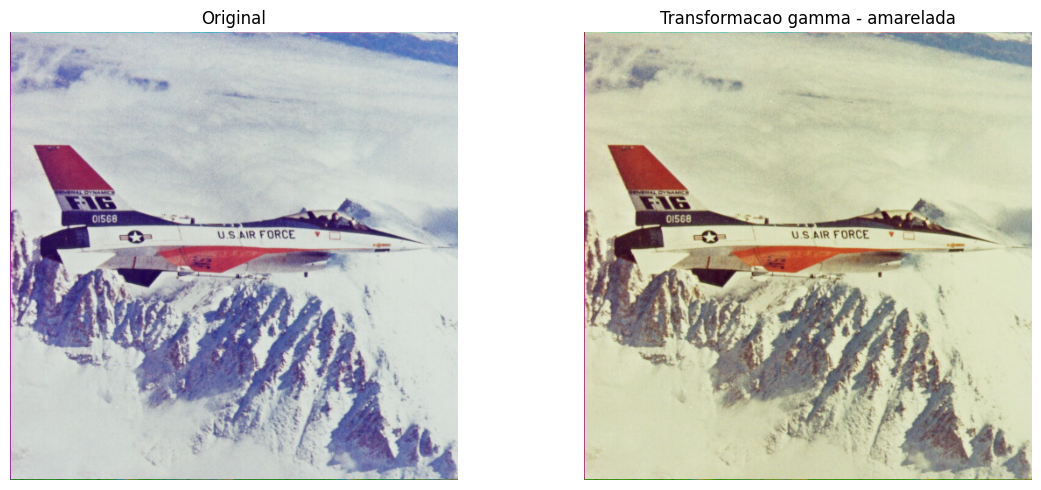

Imagem amarelada salva em: imagens\jato_amarelado.jpg


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

entrada = Path("imagens/jato.jpg")
saida = Path("imagens/jato_amarelado.jpg")

if not entrada.exists():
    raise FileNotFoundError(
        f"Arquivo nao encontrado: {entrada}. Coloque o arquivo jato.jpg na pasta imagens."
    )

imagem_original = Image.open(entrada).convert("RGB")
imagem_normalizada = np.asarray(imagem_original, dtype=np.float32) / 255.0

# Gamma menor que 1 clareia vermelho/verde; gamma maior que 1 escurece o azul.
gamma_rgb = np.array([0.80, 0.85, 1.60], dtype=np.float32)
imagem_gamma = imagem_normalizada ** gamma_rgb
imagem_amarelada_array = np.clip(imagem_gamma * 255, 0, 255).astype(np.uint8)
imagem_amarelada = Image.fromarray(imagem_amarelada_array)

saida.parent.mkdir(parents=True, exist_ok=True)
imagem_amarelada.save(saida)

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

eixos[0].imshow(imagem_original)
eixos[0].set_title("Original")
eixos[0].axis("off")

eixos[1].imshow(imagem_amarelada)
eixos[1].set_title("Transformacao gamma - amarelada")
eixos[1].axis("off")

plt.tight_layout()
plt.show()

print(f"Imagem amarelada salva em: {saida}")
